# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Link Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# CHOICE 1: FROM GOOGLE DRIVE
#df = pd.read_csv('/content/drive/MyDrive/data.csv')

# CHOICE 2: DIRECT UPLOAD
df = pd.read_csv('/content/data.csv')

print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

## Dataset Overview

In [ ]:
print("\n Dataset Information:\n")
print(df.info())
print("\n Dataset Shape:\n",df.shape)


 Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.co

## Customer Demographics Analysis

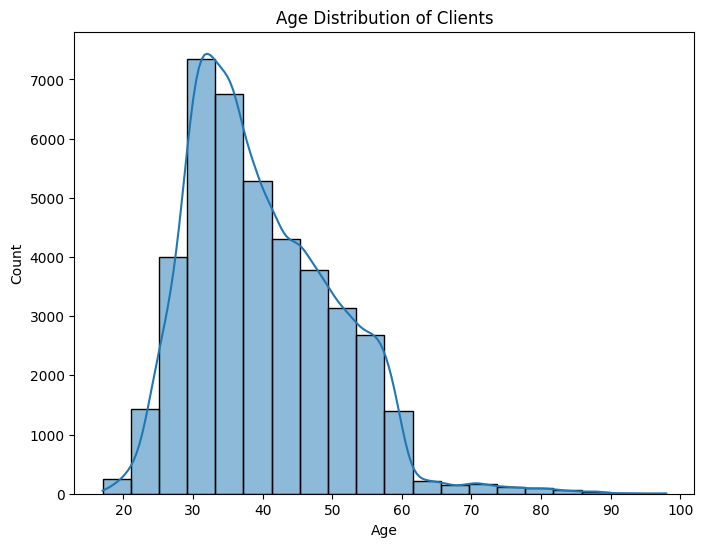

In [ ]:
# Age distribution
plt.figure(figsize=(8,6))

sns.histplot(df['age'], bins=20, kde=True)

plt.title('Age Distribution of Clients')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

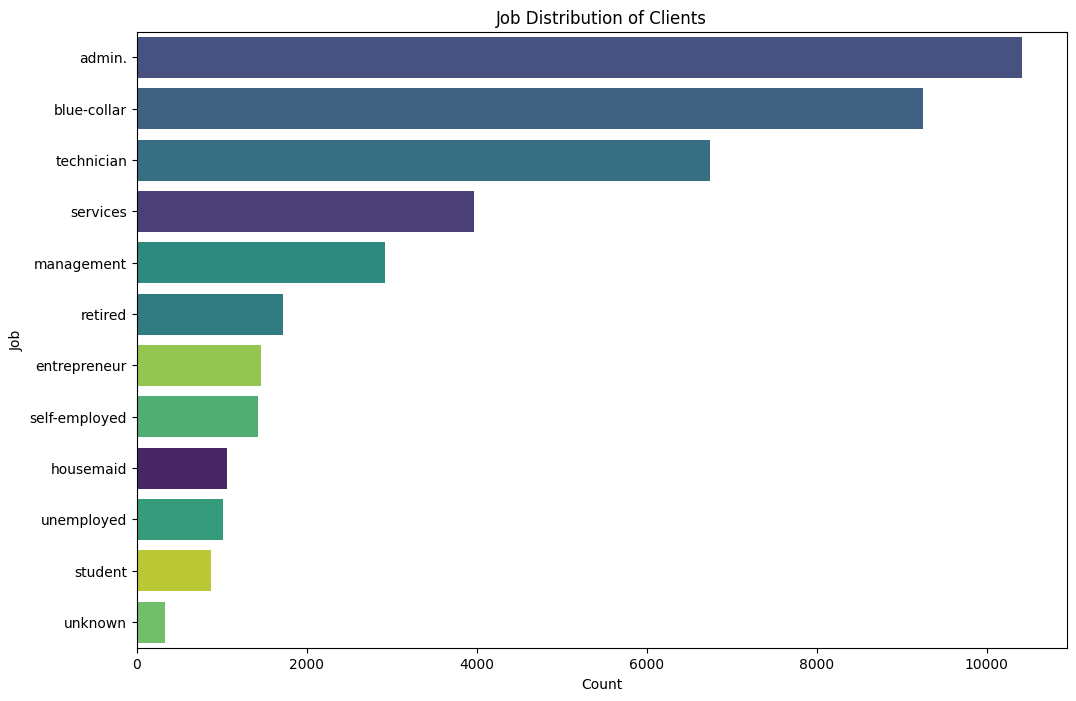

In [ ]:
# Job distribution
plt.figure(figsize=(12, 8))

sns.countplot(y='job', data=df,
              order=df['job'].value_counts().index,
              palette='viridis',
              hue='job',
              legend=False)

plt.title('Job Distribution of Clients')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()


## Call Duration & Deposit Trends

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


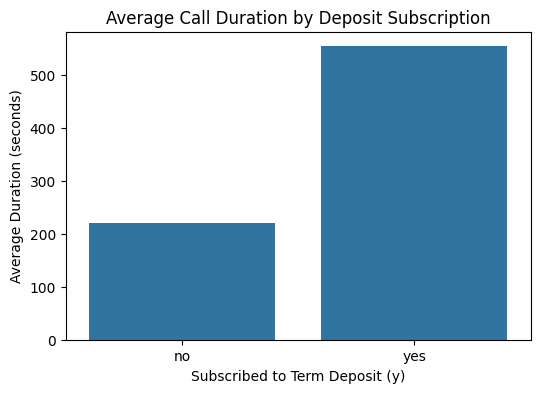

In [ ]:
# For average balance by deposit subscription
# Used 'duration' (call length) instead of 'balance' because this dataset has no balance column.
# Duration is the only per-client numeric field that reflects individual behavior, similar to how balance would.

# Average call duration by deposit subscription
avg_duration = df.groupby('y')['duration'].mean()
print(avg_duration)

plt.figure(figsize=(6, 4))
sns.barplot(x=avg_duration.index, y=avg_duration.values)
plt.title('Average Call Duration by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Average Duration (seconds)')
plt.show()

## Campaign Effectiveness

contact
cellular     26144
telephone    15044
Name: count, dtype: int64


/tmp/ipykernel_3137/1518915851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='contact', data=df, palette='viridis')


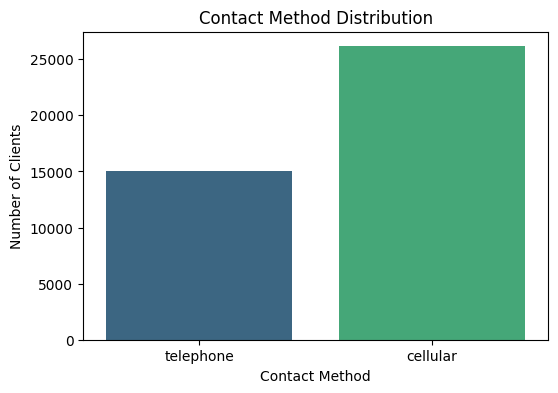

y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


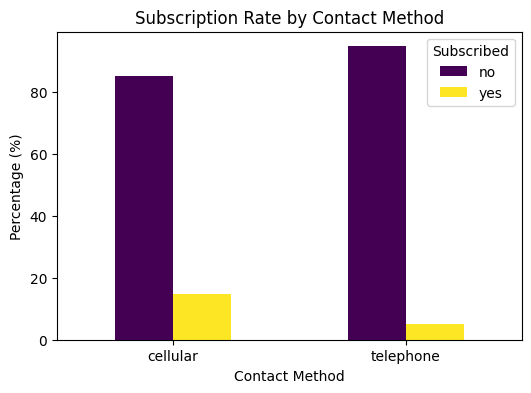

In [ ]:
# Contact method analysis
contact_counts = df['contact'].value_counts()
print(contact_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='contact', data=df, palette='viridis')
plt.title('Contact Method Distribution')
plt.xlabel('Contact Method')
plt.ylabel('Number of Clients')
plt.show()

# Contact method effectiveness (cellular vs telephone) by subscription
contact_effect = pd.crosstab(df['contact'], df['y'],
                             normalize='index') * 100
print(contact_effect)

contact_effect.plot(kind='bar', stacked=False,
                    figsize=(6, 4), colormap='viridis')
plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Percentage (%)')
plt.legend(title='Subscribed')
plt.xticks(rotation=0)
plt.show()


y             no   yes
contact               
cellular   22291  3853
telephone  14257   787


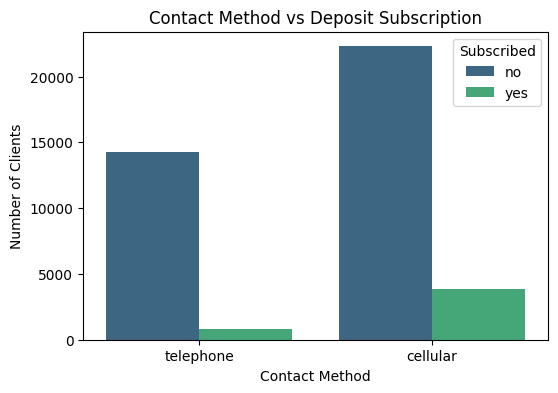

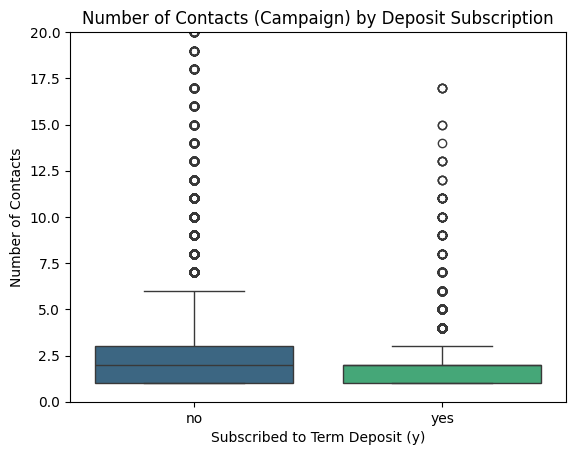

In [ ]:
# Number of contacts vs deposit subscription
contact_counts = df.groupby(['contact', 'y']).size().unstack()
print(contact_counts)

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='contact', hue='y', palette='viridis')
plt.title('Contact Method vs Deposit Subscription')
plt.xlabel('Contact Method')
plt.ylabel('Number of Clients')
plt.legend(title='Subscribed')

plt.show()

sns.boxplot(x='y', y='campaign',hue='y', data=df, palette='viridis', legend=False)
plt.title('Number of Contacts (Campaign) by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Number of Contacts')
plt.ylim(0, 20)  # zoom in, campaign has outliers

plt.show()

## Correlation Heatmap

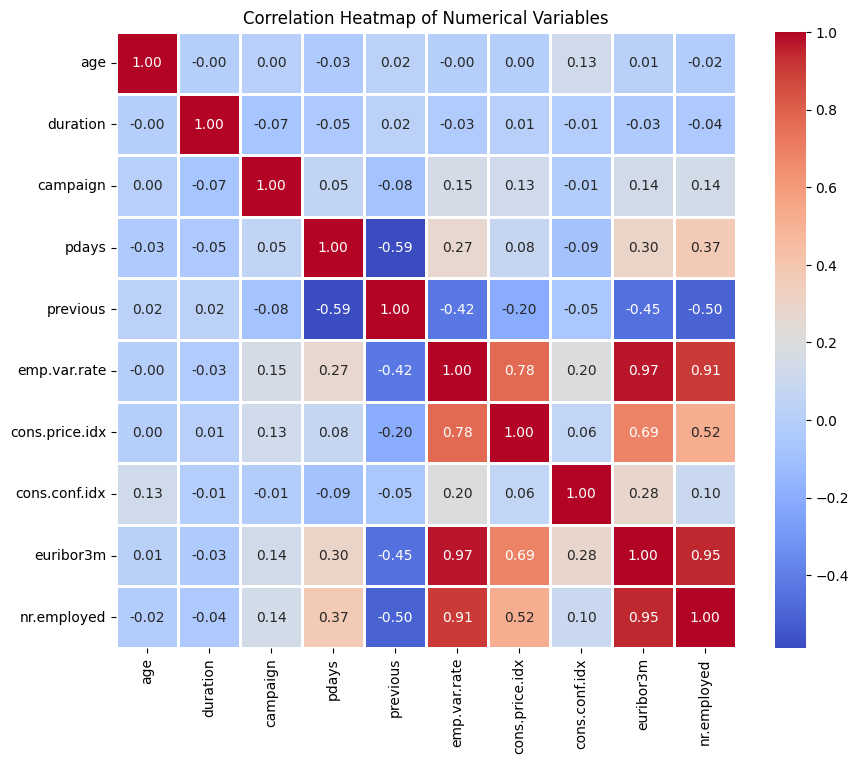

In [ ]:
# Correlation of numerical variables

numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous','emp.var.rate',
                'cons.price.idx', 'cons.conf.idx','euribor3m', 'nr.employed']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths= 1)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

## Predictive Modeling (Logistic Regression)

In [ ]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df_encoded.drop('y_yes', axis=1)
y = df_encoded['y_yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features to fix convergence warning
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9115076474872542
              precision    recall  f1-score   support

       False       0.93      0.97      0.95      7303
        True       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



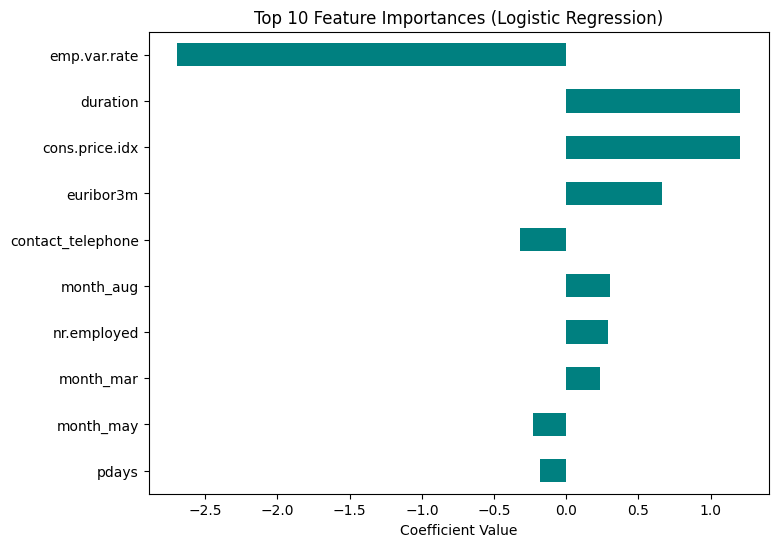

In [ ]:
# Feature importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
importance.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher call duration correlates with higher subscription rates.
 (*This dataset has no balance field, so call duration was used as the closest available proxy*).
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.